In [30]:
# Data handling libraries
import pandas as pd
import numpy as np

# Plotting library
import matplotlib.pyplot as plt

# Preprocessing and model selection tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# For saving the trained model
import joblib

# Makes sure our plots show up nicely inside the notebook
%matplotlib inline

print("All libraries imported successfully.")

All libraries imported successfully.


In [31]:
# Load the raw dataset (no header row present in the file)
heart_data = pd.read_csv("processed.cleveland.data", header=None)

print("Dataset loaded successfully.")
print("Raw shape (rows, columns):", heart_data.shape)

Dataset loaded successfully.
Raw shape (rows, columns): (303, 14)


In [32]:
#Official UCI column names, in the same order as the raw data file
column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

# Assign the column names to the dataset
heart_data.columns = column_names

print("Column names assigned successfully.")
heart_data.head()

Column names assigned successfully.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [33]:
# Shape of the dataset (rows, columns)
print("Shape of the dataset:", heart_data.shape)

Shape of the dataset: (303, 14)


In [34]:
# Data types and non-null counts of each column
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [35]:
#Statistical summary of numeric columns
# Note: at this point 'ca' and 'thal' still contain the text "?" for missing values,
# so pandas currently treats them as text (object) columns and they will not appear
# in this numeric summary. We fix their data type in the Data Cleaning section.
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [36]:
# Count of missing values in each column
# At this stage, missing values are still stored as the string "?", so pandas'
# isnull() will NOT detect them yet — this only shows genuine NaN cells (there are none yet).
print("Missing values (before replacing '?'):")
print(heart_data.isnull().sum())

Missing values (before replacing '?'):
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [37]:
# Check how many rows contain the "?" placeholder for missing values
question_mark_counts = (heart_data == "?").sum()
print("Count of '?' placeholders per column:")
print(question_mark_counts)


Count of '?' placeholders per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [38]:
# Check for duplicate rows in the dataset
print("Number of duplicate rows:", heart_data.duplicated().sum())

Number of duplicate rows: 0


In [39]:
# Number of unique values in each column
# This helps us understand which columns are categorical (few unique values)
# and which are continuous (many unique values)
print("Unique values per column:")
print(heart_data.nunique())

Unique values per column:
age          41
sex           2
cp            4
trestbps     50
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        5
dtype: int64


Target value counts (raw, 0-4 scale):
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


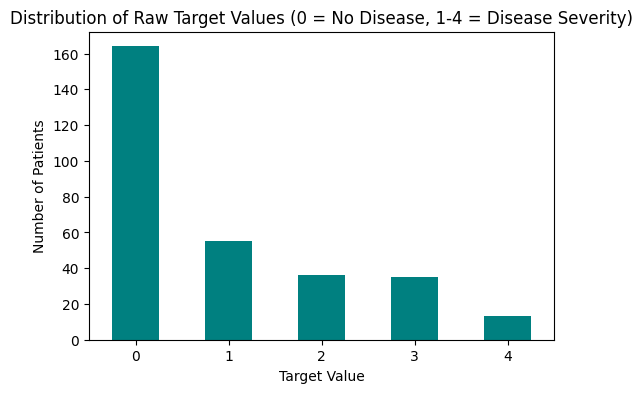

In [40]:
# Distribution of the target column (before converting it to binary)
# Values 0-4 represent increasing severity of heart disease, 0 meaning no disease
print("Target value counts (raw, 0-4 scale):")
print(heart_data["target"].value_counts().sort_index())

# Visualize the raw target distribution
plt.figure(figsize=(6, 4))
heart_data["target"].value_counts().sort_index().plot(kind="bar", color="teal")
plt.title("Distribution of Raw Target Values (0 = No Disease, 1-4 = Disease Severity)")
plt.xlabel("Target Value")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

In [41]:
# Decision 1: Replace the "?" placeholder with proper NaN (missing) values
heart_data = heart_data.replace("?", np.nan)

print("Replaced '?' with NaN successfully.")
print("Missing values per column now:")
print(heart_data.isnull().sum())

Replaced '?' with NaN successfully.
Missing values per column now:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [42]:
# Decision 2: Convert every column to numeric (float) data type
# 'ca' and 'thal' were loaded as text (object) because of the "?" values,
# so we explicitly convert the whole dataset to float now that "?" is gone
heart_data = heart_data.astype(float)

print("Data types after conversion:")
print(heart_data.dtypes)

Data types after conversion:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target      float64
dtype: object


In [43]:
# Decision 3: Handle the missing values in 'ca' and 'thal'

# 'ca' is a numeric count of vessels -> fill missing values with the median
ca_median = heart_data["ca"].median()
heart_data["ca"] = heart_data["ca"].fillna(ca_median)

# 'thal' is a coded categorical value -> fill missing values with the mode (most common category)
thal_mode = heart_data["thal"].mode()[0]
heart_data["thal"] = heart_data["thal"].fillna(thal_mode)

print("Filled 'ca' missing values with median:", ca_median)
print("Filled 'thal' missing values with mode:", thal_mode)
print()
print("Missing values remaining in the dataset:")
print(heart_data.isnull().sum().sum())

Filled 'ca' missing values with median: 0.0
Filled 'thal' missing values with mode: 3.0

Missing values remaining in the dataset:
0


Binary target value counts:
target
0    164
1    139
Name: count, dtype: int64


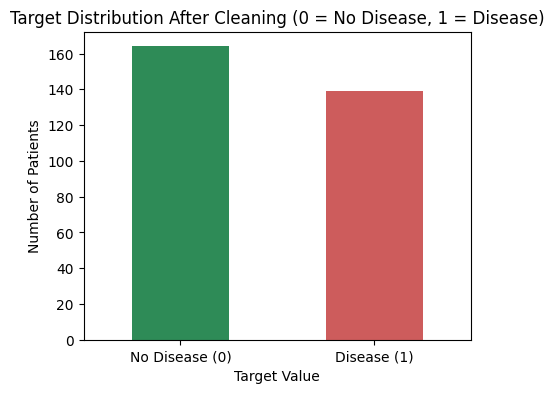

In [44]:
# Decision 4: Convert the target column into a binary classification target
# 0 = no heart disease, 1 = heart disease present (any severity level 1-4 becomes 1)
heart_data["target"] = (heart_data["target"] > 0).astype(int)

print("Binary target value counts:")
print(heart_data["target"].value_counts())

# Visualize the cleaned, binary target distribution
plt.figure(figsize=(5, 4))
heart_data["target"].value_counts().sort_index().plot(kind="bar", color=["seagreen", "indianred"])
plt.title("Target Distribution After Cleaning (0 = No Disease, 1 = Disease)")
plt.xlabel("Target Value")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease (0)", "Disease (1)"], rotation=0)
plt.show()

In [45]:
# Final check of the cleaned dataset
print("Final shape of cleaned dataset:", heart_data.shape)
heart_data.describe()

Final shape of cleaned dataset: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [46]:
# X = all feature columns (everything except the target)
X = heart_data.drop("target", axis=1)

# y = the target column we want to predict
y = heart_data["target"]

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)
X.head()

Shape of X (features): (303, 13)
Shape of y (target): (303,)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0


In [47]:
# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print()
print("Target distribution in training set:")
print(y_train.value_counts(normalize=True))
print()
print("Target distribution in testing set:")
print(y_test.value_counts(normalize=True))

Training set shape: (242, 13)
Testing set shape: (61, 13)

Target distribution in training set:
target
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Target distribution in testing set:
target
0    0.540984
1    0.459016
Name: proportion, dtype: float64


In [48]:
# Create a StandardScaler and fit it ONLY on the training data
# (fitting on test data would leak information from the test set into training)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling transformation to the test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")
print("Mean of scaled training features (should be ~0):", np.round(X_train_scaled.mean(), 4))
print("Std of scaled training features (should be ~1):", np.round(X_train_scaled.std(), 4))

Feature scaling complete.
Mean of scaled training features (should be ~0): -0.0
Std of scaled training features (should be ~1): 1.0


In [49]:
# We will store each model's results (as a dictionary) in this list,
# then turn it into a comparison table later
model_results = []

In [50]:
# Train Logistic Regression on the scaled training data
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train_scaled, y_train)

# Predict on the scaled test data
log_reg_predictions = log_reg_model.predict(X_test_scaled)
log_reg_probabilities = log_reg_model.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
log_reg_accuracy = accuracy_score(y_test, log_reg_predictions)
log_reg_precision = precision_score(y_test, log_reg_predictions)
log_reg_recall = recall_score(y_test, log_reg_predictions)
log_reg_f1 = f1_score(y_test, log_reg_predictions)
log_reg_roc_auc = roc_auc_score(y_test, log_reg_probabilities)

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy: ", round(log_reg_accuracy, 4))
print("Precision:", round(log_reg_precision, 4))
print("Recall:   ", round(log_reg_recall, 4))
print("F1 Score: ", round(log_reg_f1, 4))
print("ROC-AUC:  ", round(log_reg_roc_auc, 4))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, log_reg_predictions))
print()
print("Classification Report:")
print(classification_report(y_test, log_reg_predictions))

# Save results for comparison table
model_results.append({
    "Model": "Logistic Regression",
    "Accuracy": log_reg_accuracy,
    "Precision": log_reg_precision,
    "Recall": log_reg_recall,
    "F1 Score": log_reg_f1,
    "ROC-AUC": log_reg_roc_auc
})

LOGISTIC REGRESSION RESULTS
Accuracy:  0.8689
Precision: 0.8125
Recall:    0.9286
F1 Score:  0.8667
ROC-AUC:   0.9513

Confusion Matrix:
[[27  6]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [51]:
# Train SVM on the scaled training data
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predict on the scaled test data
svm_predictions = svm_model.predict(X_test_scaled)
svm_probabilities = svm_model.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions)
svm_recall = recall_score(y_test, svm_predictions)
svm_f1 = f1_score(y_test, svm_predictions)
svm_roc_auc = roc_auc_score(y_test, svm_probabilities)

print("SUPPORT VECTOR MACHINE RESULTS")
print("Accuracy: ", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall:   ", round(svm_recall, 4))
print("F1 Score: ", round(svm_f1, 4))
print("ROC-AUC:  ", round(svm_roc_auc, 4))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_predictions))
print()
print("Classification Report:")
print(classification_report(y_test, svm_predictions))

# Save results for comparison table
model_results.append({
    "Model": "SVM",
    "Accuracy": svm_accuracy,
    "Precision": svm_precision,
    "Recall": svm_recall,
    "F1 Score": svm_f1,
    "ROC-AUC": svm_roc_auc
})

SUPPORT VECTOR MACHINE RESULTS
Accuracy:  0.8525
Precision: 0.8065
Recall:    0.8929
F1 Score:  0.8475
ROC-AUC:   0.9437

Confusion Matrix:
[[27  6]
 [ 3 25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



In [52]:
# Train Random Forest on the original (unscaled) training data
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the original (unscaled) test data
rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_roc_auc = roc_auc_score(y_test, rf_probabilities)

print("RANDOM FOREST RESULTS")
print("Accuracy: ", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:   ", round(rf_recall, 4))
print("F1 Score: ", round(rf_f1, 4))
print("ROC-AUC:  ", round(rf_roc_auc, 4))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))
print()
print("Classification Report:")
print(classification_report(y_test, rf_predictions))

# Save results for comparison table
model_results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "ROC-AUC": rf_roc_auc
})

RANDOM FOREST RESULTS
Accuracy:  0.8852
Precision: 0.8387
Recall:    0.9286
F1 Score:  0.8814
ROC-AUC:   0.9518

Confusion Matrix:
[[28  5]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [53]:
# Train XGBoost on the original (unscaled) training data
xgb_model = XGBClassifier(random_state=42, eval_metric="logloss")
xgb_model.fit(X_train, y_train)

# Predict on the original (unscaled) test data
xgb_predictions = xgb_model.predict(X_test)
xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_precision = precision_score(y_test, xgb_predictions)
xgb_recall = recall_score(y_test, xgb_predictions)
xgb_f1 = f1_score(y_test, xgb_predictions)
xgb_roc_auc = roc_auc_score(y_test, xgb_probabilities)

print("XGBOOST RESULTS")
print("Accuracy: ", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall:   ", round(xgb_recall, 4))
print("F1 Score: ", round(xgb_f1, 4))
print("ROC-AUC:  ", round(xgb_roc_auc, 4))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_predictions))
print()
print("Classification Report:")
print(classification_report(y_test, xgb_predictions))

# Save results for comparison table
model_results.append({
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1,
    "ROC-AUC": xgb_roc_auc
})

XGBOOST RESULTS
Accuracy:  0.8525
Precision: 0.7879
Recall:    0.9286
F1 Score:  0.8525
ROC-AUC:   0.9188

Confusion Matrix:
[[26  7]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.79      0.85        33
           1       0.79      0.93      0.85        28

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



In [54]:
# Build a comparison table from the results we collected for each model
comparison_table = pd.DataFrame(model_results)

# Sort by F1 Score (a balanced metric of precision and recall) in descending order
comparison_table = comparison_table.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

print("Model Comparison Table:")
comparison_table

Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.885246,0.838710,0.928571,0.881356,0.951840
1,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
2,XGBoost,0.852459,0.787879,0.928571,0.852459,0.918831
3,SVM,0.852459,0.806452,0.892857,0.847458,0.943723


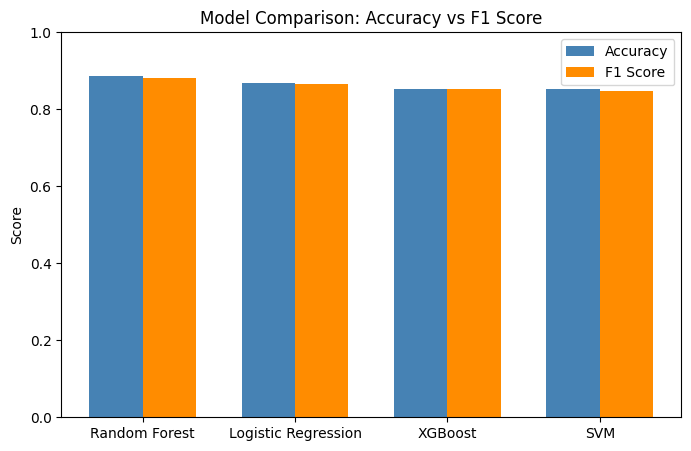

In [55]:
plt.figure(figsize=(8, 5))
bar_width = 0.35
x_positions = np.arange(len(comparison_table))

plt.bar(x_positions - bar_width / 2, comparison_table["Accuracy"], width=bar_width, label="Accuracy", color="steelblue")
plt.bar(x_positions + bar_width / 2, comparison_table["F1 Score"], width=bar_width, label="F1 Score", color="darkorange")

plt.xticks(x_positions, comparison_table["Model"])
plt.ylabel("Score")
plt.title("Model Comparison: Accuracy vs F1 Score")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [56]:
best_model_name = comparison_table.loc[0, "Model"]
print("Best performing model based on F1 Score:", best_model_name)

Best performing model based on F1 Score: Random Forest


In [57]:
# Define the grid of hyperparameter values to search over
parameter_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Set up GridSearchCV: 5-fold cross-validation, optimizing for F1 Score
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=parameter_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Run the grid search on the training data (Random Forest does not need scaled data)
grid_search.fit(X_train, y_train)

print("Best hyperparameters found:")
print(grid_search.best_params_)
print()
print("Best cross-validation F1 Score:", round(grid_search.best_score_, 4))

Best hyperparameters found:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best cross-validation F1 Score: 0.8106


In [58]:
# Extract the best model found by GridSearchCV
final_model = grid_search.best_estimator_

# Predict on the test set with the tuned final model
final_predictions = final_model.predict(X_test)
final_probabilities = final_model.predict_proba(X_test)[:, 1]

# Evaluate the final tuned model
final_accuracy = accuracy_score(y_test, final_predictions)
final_precision = precision_score(y_test, final_predictions)
final_recall = recall_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions)
final_roc_auc = roc_auc_score(y_test, final_probabilities)

print("FINAL TUNED RANDOM FOREST RESULTS")
print("Accuracy: ", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall:   ", round(final_recall, 4))
print("F1 Score: ", round(final_f1, 4))
print("ROC-AUC:  ", round(final_roc_auc, 4))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, final_predictions))
print()
print("Classification Report:")
print(classification_report(y_test, final_predictions))

FINAL TUNED RANDOM FOREST RESULTS
Accuracy:  0.9016
Precision: 0.8667
Recall:    0.9286
F1 Score:  0.8966
ROC-AUC:   0.9481

Confusion Matrix:
[[29  4]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



In [59]:
# Compare the tuned final model against the original (untuned) Random Forest
tuning_comparison = pd.DataFrame([
    {"Model": "Random Forest (Before Tuning)", "Accuracy": rf_accuracy, "Precision": rf_precision,
     "Recall": rf_recall, "F1 Score": rf_f1, "ROC-AUC": rf_roc_auc},
    {"Model": "Random Forest (After Tuning)", "Accuracy": final_accuracy, "Precision": final_precision,
     "Recall": final_recall, "F1 Score": final_f1, "ROC-AUC": final_roc_auc}
])

print("Effect of Hyperparameter Tuning:")
tuning_comparison

Effect of Hyperparameter Tuning:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest (Before Tuning),0.885246,0.838710,0.928571,0.881356,0.951840
1,Random Forest (After Tuning),0.901639,0.866667,0.928571,0.896552,0.948052


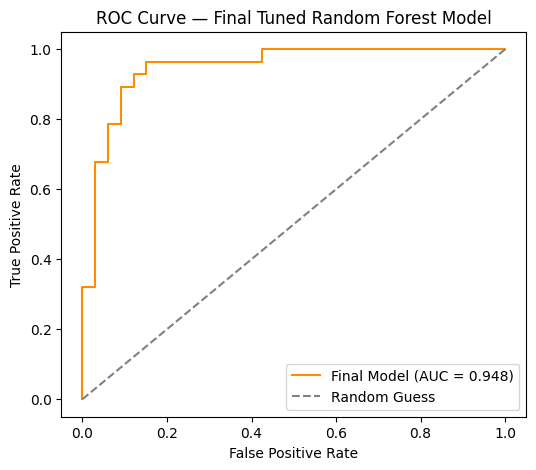

In [60]:
# Plot the ROC curve of the final tuned model
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, final_probabilities)

plt.figure(figsize=(6, 5))
plt.plot(false_positive_rate, true_positive_rate, color="darkorange", label="Final Model (AUC = %.3f)" % final_roc_auc)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Tuned Random Forest Model")
plt.legend(loc="lower right")
plt.show()

In [61]:
# Extract feature importance values from the final tuned model
feature_importance_values = final_model.feature_importances_

# Build a DataFrame pairing each feature name with its importance score
feature_importance_table = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance_values
})

# Sort features from most to least important
feature_importance_table = feature_importance_table.sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("Feature Importance Table:")
feature_importance_table

Feature Importance Table:


,Feature,Importance
0,thal,0.178928
1,cp,0.142170
2,thalach,0.123829
3,ca,0.116961
4,oldpeak,0.091049
5,exang,0.062537
6,trestbps,0.058962
7,age,0.057736
8,chol,0.056094
9,slope,0.048985


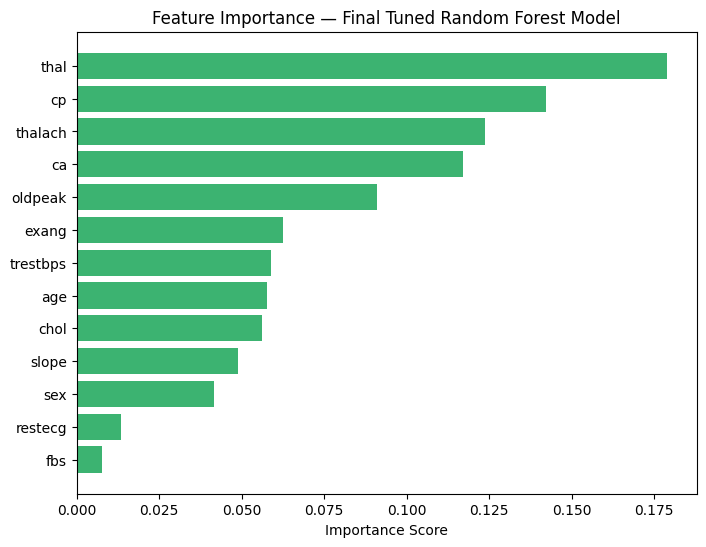

In [62]:
# Visualize feature importance as a horizontal bar chart
plt.figure(figsize=(8, 6))
plt.barh(feature_importance_table["Feature"], feature_importance_table["Importance"], color="mediumseagreen")
plt.xlabel("Importance Score")
plt.title("Feature Importance — Final Tuned Random Forest Model")
plt.gca().invert_yaxis()  # Most important feature on top
plt.show()

In [63]:
# Save the final trained Random Forest model to disk
joblib.dump(final_model, "final_heart_disease_model.pkl")

# Save the fitted scaler as well, for consistency with the rest of the pipeline
joblib.dump(scaler, "feature_scaler.pkl")

print("Final model saved as 'final_heart_disease_model.pkl'")
print("Scaler saved as 'feature_scaler.pkl'")

Final model saved as 'final_heart_disease_model.pkl'
Scaler saved as 'feature_scaler.pkl'


In [64]:
# Reload the saved model (this shows how the model would be used later, independently
# of the training code above)
loaded_model = joblib.load("final_heart_disease_model.pkl")

# Collect patient information from the user, one value at a time
print("Please enter the patient's clinical information below:")
print()

patient_age = float(input("Age (years): "))
patient_sex = float(input("Sex (1 = male, 0 = female): "))
patient_cp = float(input("Chest pain type (1-4): "))
patient_trestbps = float(input("Resting blood pressure (mm Hg): "))
patient_chol = float(input("Serum cholesterol (mg/dl): "))
patient_fbs = float(input("Fasting blood sugar > 120 mg/dl (1 = true, 0 = false): "))
patient_restecg = float(input("Resting electrocardiographic results (0-2): "))
patient_thalach = float(input("Maximum heart rate achieved: "))
patient_exang = float(input("Exercise induced angina (1 = yes, 0 = no): "))
patient_oldpeak = float(input("ST depression induced by exercise (oldpeak): "))
patient_slope = float(input("Slope of the peak exercise ST segment (1-3): "))
patient_ca = float(input("Number of major vessels colored by fluoroscopy (0-3): "))
patient_thal = float(input("Thalassemia (3 = normal, 6 = fixed defect, 7 = reversible defect): "))

print()
print("All patient information collected successfully.")

Please enter the patient's clinical information below:


All patient information collected successfully.


In [65]:
# Apply the SAME preprocessing used during training:
# Build a single-row DataFrame with the same column names and order as X
new_patient_data = pd.DataFrame([{
    "age": patient_age,
    "sex": patient_sex,
    "cp": patient_cp,
    "trestbps": patient_trestbps,
    "chol": patient_chol,
    "fbs": patient_fbs,
    "restecg": patient_restecg,
    "thalach": patient_thalach,
    "exang": patient_exang,
    "oldpeak": patient_oldpeak,
    "slope": patient_slope,
    "ca": patient_ca,
    "thal": patient_thal
}])

# Note: the final model is a Random Forest, which was trained on UNSCALED features,
# so we pass the new patient data directly without scaling (matching training step 9.3/14)
predicted_class = loaded_model.predict(new_patient_data)[0]
predicted_probability = loaded_model.predict_proba(new_patient_data)[0]

print("=" * 45)
print("HEART DISEASE PREDICTION RESULT")
print("=" * 45)

if predicted_class == 1:
    print("Predicted Class: 1 -> Heart Disease Present")
else:
    print("Predicted Class: 0 -> No Heart Disease")

print()
print("Prediction Probability:")
print("  No Disease (0): %.2f%%" % (predicted_probability[0] * 100))
print("  Disease (1):    %.2f%%" % (predicted_probability[1] * 100))
print("=" * 45)
print()
print("Note: This prediction is generated by a machine learning model for educational")
print("purposes only and must NOT be used as an actual medical diagnosis. Always consult")
print("a qualified healthcare professional for real medical advice.")

HEART DISEASE PREDICTION RESULT
Predicted Class: 0 -> No Heart Disease

Prediction Probability:
  No Disease (0): 51.34%
  Disease (1):    48.66%

Note: This prediction is generated by a machine learning model for educational
purposes only and must NOT be used as an actual medical diagnosis. Always consult
a qualified healthcare professional for real medical advice.
